How it should work:

Iterate over all folders.
if background folder create background.
Do med projection and save it in that folder
if not, use generic background.
(generated before).


delete original ome tiff file? better not just in case

In [121]:
#import pckgs
import cv2
import tifffile as tiff
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import os
from natsort import natsorted

from scipy.interpolate import splprep, splev

from skimage.morphology import medial_axis, skeletonize
from skimage import data
from skimage.util import invert
import skimage.graph

In [2]:
#define default output path
output_path='/groups/zimmer/Ulises/code/skeleton_outputs/'
try: os.mkdir(output_path)
except: print('Output Directory already exists')

Output Directory already exists


In [3]:
#background image, obtained from fiji
#develop further to get a z-projection in here, or use a bg image generated in fiji
bg_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/20200701/2020-07-01_13-42-05_chemotaxisl_worm1_bg-channel-0-/'
bg_file='2020-07-01_13-42-05_chemotaxisl_worm1_bg-channel-0-_MMStack.ome.tif'
bg_file_path=bg_path+bg_file
retval, mats=cv2.imreadmulti(bg_file_path)


In [7]:
bg_video=np.asarray(mats)
print(bg_video.shape)
bg_video_med=np.median(bg_video, axis=0).astype(dtype=np.uint8)  
print(bg_video_med.shape)
bg_video_med=cv2.bitwise_not(bg_video_med)

tiff.imsave(output_path+'bg_img.tiff',bg_video)
tiff.imsave(output_path+'bg_img_med.tiff',bg_video_med)

(961, 610, 608)
(610, 608)


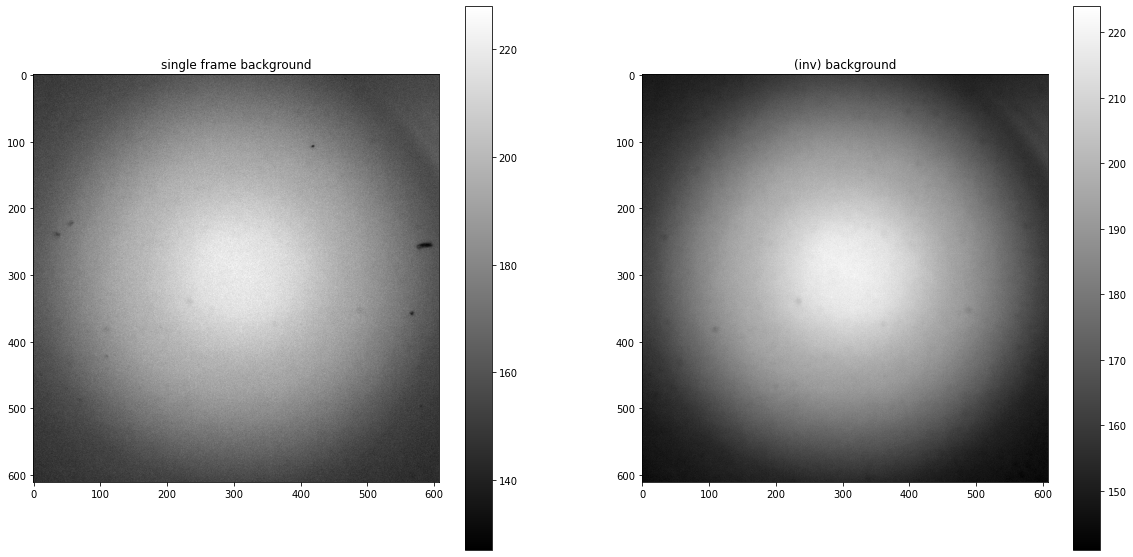

In [26]:
#show background

plt.figure(figsize=(20,10))
plt.subplot(1,2,1)
plt.imshow(bg_video[0],cmap='gray')
plt.title('single frame background')
plt.colorbar()
plt.subplot(1,2,2)
plt.imshow(bg_video_med,cmap='gray')
plt.title('(inv) background')
plt.colorbar()

## Actual code

In [122]:
#import pckgs
import cv2
import tifffile as tiff
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import os
from natsort import natsorted

from scipy.interpolate import splprep, splev

from skimage.morphology import medial_axis, skeletonize
from skimage import data
from skimage.util import invert
import skimage.graph

In [123]:
#calculate median and do inverse function
def median_and_inverse(bg_file_path):
    retval, mats=cv2.imreadmulti(bg_file_path)
    bg_video=np.asarray(mats)
    bg_video_med=np.median(bg_video, axis=0).astype(dtype=np.uint8)  
    bg_video_med=cv2.bitwise_not(bg_video_med)
    return bg_video_med


In [125]:
#iterates on all folders inside the main path that have 'bg' and creates a MED projection on the tiff files.
#trying to make it for worms only directories
main_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/'

for dataset in natsorted(os.listdir(main_path)):
#dataset prefix is hard coded
#print(i)
    if dataset.startswith('dataset_'):
        #print(dataset)
        #for every recording inside the dataset
        for worm in natsorted(os.listdir(os.path.join(main_path,dataset))):
            #if worm is a directory (to ignore other files)
            if os.path.isdir(os.path.join(main_path,dataset,worm)):
                for files in natsorted(os.listdir(os.path.join(main_path,dataset,worm))):
                    if 'bg' in files:# and files.endswith('ome.tif'):
                            for bg_files in natsorted(os.listdir(os.path.join(main_path,dataset,worm,files))):
                                if bg_files.endswith('.ome.tif'):
                                    print('actual background file is : '+bg_files)
                                    #tiff save the ouput of median_and_inverse in the worm directory with filename: 'worm+_median_bg.tiff'
                                    tiff.imsave(os.path.join(main_path,dataset,worm,files)+'_median_bg.tiff',median_and_inverse(os.path.join(main_path,dataset,worm,files,bg_files)))
                #else: print (worm+'is not a bg directory')
print('done')        #I could add code here to process the X,Y stage positions with the  TablePosRecord.txt

actual background file is : 2020-06-08_11-56-54_control_worm3_bg-channel-0-_MMStack.ome.tif
actual background file is : 2020-06-08_15-55-28_chemo_worm2_bg-channel-0-_MMStack.ome.tif
actual background file is : 2020-06-08_16-25-20_chemo_worm3_bg-channel-0-_MMStack.ome.tif
actual background file is : 2020-06-09_10-21-16_control_worm1_bg-channel-0-_MMStack.ome.tif
actual background file is : 2020-06-09_11-04-23_control_worm2_bg-channel-0-_MMStack.ome.tif
actual background file is : 2020-06-09_11-29-47_control_worm3_bg-channel-0-_MMStack.ome.tif
actual background file is : 2020-06-09_12-02-30_control_worm4_bg-channel-0-_MMStack.ome.tif
actual background file is : 2020-06-09_13-13-14_control_worm5_bg-channel-0-_MMStack.ome.tif
actual background file is : 2020-06-09_13-52-57_chemotaxis_worm1_bg-channel-0-_MMStack.ome.tif
actual background file is : 2020-06-09_15-06-45_chemotaxis_worm3_bg-channel-0-_MMStack.ome.tif
actual background file is : 2020-06-09_15-46-17_chemotaxis_worm4_bg-channel-0-

In [129]:
os.path.join(main_path,dataset,worm,files,bg_files)

'/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/dataset_20200701/x_refs.txt/DisplaySettings.json/DisplaySettings.json'

In [114]:
os.path.join(main_path,dataset,worm,files,bg_files)+'_median_bg.tiff'

'/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/dataset_20200701/x_refs.txt/DisplaySettings.json/DisplaySettings.json_median_bg.tiff'

In [120]:
#iterates on all folders inside the main path that have 'bg' and creates a MED projection on the tiff files.
main_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/'

for dataset in natsorted(os.listdir(main_path)):
#dataset prefix is hard coded
#print(i)
    if dataset.startswith('dataset_'):
        #print(dataset)
        #for every recording inside the dataset
        for worm in natsorted(os.listdir(os.path.join(main_path,dataset))):
            #if worm is a directory (to ignore other files)
            if os.path.isdir(os.path.join(main_path,dataset,worm)):
                print('                '+worm)
                #if worm has background folder
                for files in os.listdir(os.path.join(main_path,dataset,worm)):
                    if 'bg' in files:
                        #print(bg_files)
                        for bg_files in os.listdir(os.path.join(main_path,dataset,worm,bg_files)):
                            if files.endswith('ome.tif'):
                                print('actual background file is : '+bg_files)
                            #print(os.path.join(main_path,dataset,worm,bg_files))
                            #tiff save the ouput of median_and_inverse in the worm directory with filename: 'worm+_median_bg.tiff'
                            #tiff.imsave(os.path.join(main_path,dataset,worm,worm)+'_median_bg.tiff',median_and_inverse(os.path.join(main_path,dataset,worm,bg_files)))
                #else: print (worm+'is not a bg directory')
print('done')        #I could add code here to process the X,Y stage positions with the  TablePosRecord.txt

                2020-06-05_16-46-41_worm1-channel-0-
                2020-06-05_18-01-23_worm4-channel-0-
                2020-06-05_18-30-39_worm6-channel-0-
                2020-06-05_19-00-03_worm7-channel-0-
                2020-06-05_19-28-25_worm9-channel-0-
                2020-06-05_19-51-45_worm10-channel-0-
                2020-06-08_10-43-05_control_worm1-channel-0-
                2020-06-08_10-50-23_control_worm2-channel-0-
                2020-06-08_11-35-19_control_worm3-channel-0-


NotADirectoryError: [Errno 20] Not a directory: '/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/dataset_20200608/2020-06-08_11-35-19_control_worm3-channel-0-/DisplaySettings.json'

In [ ]:
#iterates on all folders inside the main path that have 'bg' and creates a MED projection on the tiff files.
#trying to make it for worms only directories
main_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/'

for dataset in natsorted(os.listdir(main_path)):
#dataset prefix is hard coded
#print(i)
    if dataset.startswith('dataset_'):
        #print(dataset)
        #for every recording inside the dataset
        for worm in natsorted(os.listdir(os.path.join(main_path,dataset))):
            #if worm is a directory (to ignore other files)
            if os.path.isdir(os.path.join(main_path,dataset,worm)):
                for files in natsorted(os.listdir(os.path.join(main_path,dataset,worm))):
                    if 'bg' in files:# and files.endswith('ome.tif'):
                            for bg_files in natsorted(os.listdir(os.path.join(main_path,dataset,worm,files))):
                                if bg_files.endswith('.ome.tif'):
                                    print('actual background file is : '+bg_files)
                                    #tiff save the ouput of median_and_inverse in the worm directory with filename: 'worm+_median_bg.tiff'
                                    tiff.imsave(os.path.join(main_path,dataset,worm,files)+'_median_bg.tiff',median_and_inverse(os.path.join(main_path,dataset,worm,bg_files)))
                #else: print (worm+'is not a bg directory')
print('done')        #I could add code here to process the X,Y stage positions with the  TablePosRecord.txt

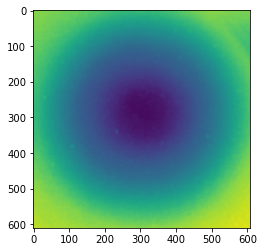

In [80]:
path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/dataset_20200609/2020-06-08_11-56-54_control_worm3_bg-channel-0-/2020-06-08_11-56-54_control_worm3_bg-channel-0-_MMStack.ome.tif'
bg_file=median_and_inverse(path)
plt.imshow(bg_file)

In [82]:
os.path.join(main_path,dataset,worm,'bg_img_med.tiff')

'/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/dataset_20200608/2020-06-08_11-56-54_control_worm3_bg-channel-0-/bg_img_med.tiff'

In [23]:
natsorted(os.listdir(os.path.join(main_path,dataset)))

['2020-06-05_16-46-41_BHrecording1-TablePosRecord.txt.tiff']

In [25]:
main_path

'/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/'

In [91]:
os.path.join(main_path,dataset,worm,worm)+'laralal'

'/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/dataset_20200609/2020-06-09_14-19-50_chemotaxis_worm2_bg-channel-0-/2020-06-09_14-19-50_chemotaxis_worm2_bg-channel-0-laralal'

In [46]:
os.path.join(main_path,dataset,worm)

'/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/dataset_20200701/x_refs.txt'

In [53]:
main_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/'

for dataset in natsorted(os.listdir(main_path)):
    #dataset prefix is hard coded
    if dataset.startswith('dataset_'):
        print(dataset)
        for worm in natsorted(os.listdir(os.path.join(main_path,dataset))):
            print(worm)

dataset_20200605
2020-06-05_16-46-41_worm1-TablePosRecord.txt
2020-06-05_16-46-41_worm1-channel-0-
2020-06-05_18-01-23_worm4-TablePosRecord.txt
2020-06-05_18-01-23_worm4-channel-0-
2020-06-05_18-30-39_worm6-channel-0-
2020-06-05_18-30-40_worm6-TablePosRecord.txt
2020-06-05_19-00-03_worm7-TablePosRecord.txt
2020-06-05_19-00-03_worm7-channel-0-
2020-06-05_19-28-25_worm9-TablePosRecord.txt
2020-06-05_19-28-25_worm9-channel-0-
2020-06-05_19-51-45_worm10-TablePosRecord.txt
2020-06-05_19-51-45_worm10-channel-0-
20200605_Roi.roi
.DS_Store
dataset_20200608
2020-06-08_10-43-05_control_worm1-TablePosRecord.txt
2020-06-08_10-43-05_control_worm1-channel-0-
2020-06-08_10-50-23_control_worm2-TablePosRecord.txt
2020-06-08_10-50-23_control_worm2-channel-0-
2020-06-08_11-35-19_control_worm3-TablePosRecord.txt
2020-06-08_11-35-19_control_worm3-channel-0-
2020-06-08_11-56-54_control_worm3_bg-TablePosRecord.txt
2020-06-08_11-56-54_control_worm3_bg-channel-0-
2020-06-08_14-11-55_chemo_worm1-TablePosRecord.